# MARKOV PROPERTY OF HAWKES PROCESSES WITH EXPONENTIAL KERNEL

## Introduction

A Hawkes process is a point process characterized by its conditional intensity, which is auto-exciting. This notebook aims to prove the Markovian character of the process $(N(t), \lambda(t \mid \mathcal{H}_t))_{t \geq 0}$.


## Analytic proof

### Presentation of the process

A Hawkes process is a point process said to be auto-exciting and which is characterized by its conditionnal intensity of the form : <br>
$$
\lambda(t \mid \mathcal{H}_t) = \nu + \int_{0}^{t^-} \mu(t-s) \, dN(s)
$$

Which is defined as 
$$
\lambda(t \mid \mathcal{H}_t) = \lim_{h \to 0^+} \frac{\mathbb{E}\left[ N(t+h) - N(t) \mid \mathcal{H}_t \right]}{h}.
$$

we will use the notation $ \lambda^\ast_t $ to denote the the conditionnal intensity with respect to $ \mathcal{H}_t $

Where : 
- $ \nu > 0 $ is the baseline intensity,

- $ \mu: \mathbb{R}_+ \to \mathbb{R}_+ $ is the exciting function

- $ N(t)$ denotes the associated counting process

- $ \mathcal{H}_t $ denotes the filtration up to time t, defined by
$$
\mathcal{H}_t = \sigma\left( N(s),\lambda^\ast_s  : 0 \leq s \leq t \right)
$$

we will restrict our study to a specific exciting function : 
$$
\mu(u) = \alpha e^{- \beta u}
$$

with $ \alpha , \beta > 0 $

### Memoryless property of $ \lambda^\ast_t $

let $ s \in (t_k,t_{k+1}] $,
$$
\begin{aligned}
\lambda^\ast_s &= \nu + \int_0^{s^-}  \alpha e^{- \beta (s - u)} \, dN(u) \\
&= \nu + \alpha \sum_{t_i \lt s} e^{-\beta (s - t_i)} \quad \text{(since $dN(t) = 1$ if t is a jump time and 0 otherwise)}\\ 
&= \nu + \alpha \sum_{t_i \lt s} e^{-\beta (s + t_k - t_k - t_i)} \\
&= \nu + \alpha e^{-\beta(s - t_k)} \sum_{t_i \leq t_k} e^{-\beta (t_k - t_i)} \\
&= \nu + (\lambda^\ast_{t_k+} - \nu) e^{-\beta (s - t_k)} \\
&= \nu + (\lambda^\ast_{t_k} + \alpha - \nu) e^{-\beta (s - t_k)}
\end{aligned}
$$

so for $ s > t_k $,
$$
\begin{aligned}
\lambda^\ast_s &=  \nu + (\lambda^\ast_{t_k} + \alpha - \nu) e^{-\beta (s - t_k)} + \alpha \sum_{t_k \lt t_i \lt s} e^{-\beta (s - t_i)}\\

\end{aligned}
$$

which only depends on $\lambda^\ast_{t_k}, t_k$ and jumps that occur after

### Markov Property

From Doob-Meyer decomposition we define the martingale $ M_t $ as

$$
N_t = M_t + \Lambda_t
$$

where $ \Lambda_t = \int_0^{t} \lambda^\ast_u \, du $ \
so ($ N_t - \Lambda_t $) is a local martingale and hence 

$$
\forall s > 0, \quad 
\mathbb{E}[N_t - \Lambda_t \mid \mathcal{H}_s] = N_s - \Lambda_s
$$
Using this equality, we can prove the Markov property
$$
\begin{aligned}
\mathbb{E}[N_t \mid \mathcal{H}_s] &= \mathbb{E}[N_t - N_s \mid \mathcal{H}_s] + N_s \quad \text{(because $N_s$ is $\mathcal{H}_s$ - measurable)}\\
&= \mathbb{E}[\Lambda_t - \Lambda_s \mid \mathcal{H}_s] + N_s \\
&= \mathbb{E}[\int_s^{t} \lambda^\ast_u \, du \mid \mathcal{H}_s] + N_s
\end{aligned}
$$

from the last cell, $ \int_s^{t} \lambda^\ast_u \, du $ only depend on the last jump before s and jumps between s and t which are not included in $ \mathcal{H}_s $ so :
$$
\mathbb{E}[N_t \mid \mathcal{H}_s] = \mathbb{E}[\int_s^{t} \lambda^\ast_u \, du \mid \mathcal{H}_s] + N_s = \mathbb{E}[\int_s^{t} \lambda^\ast_u \, du \mid N_s,\lambda^\ast_{t_{N_s}}] + N_s = \mathbb{E}[N_t \mid N_s,\lambda^\ast_{t_{N_s}}]\\
$$
Hence we can conclude that the process $ (N_t, \lambda^\ast_{t})_{t\geq0} $ is a Markovian process

## Numerical proof

### Algorithm used

#### Ogata’s modified thinning method

The goal is to simulate a point process with a time-varying intensity function $\lambda^\ast_t$.

1.  **Initialization:**

    * Set $t = 0$.

    * Initialize the event history $\mathcal{H}_0 = \emptyset \cup \Omega$.

    * Set the simulation end time $T$.

2.  **Iteration:** While $t < T$, repeat the following steps:

    * **Calculate the current conditional intensity** $\lambda(t)$:

        * Given the event history $\mathcal{H}_t = \{t_1, t_2, ..., t_n\}$ where $t_i < t$, calculate $\lambda^\ast_t$.  For a Hawkes process with an exponential kernel, this is:
            
            $$\lambda^\ast_t = \nu + \sum_{t_i \in \mathcal{H}_t} \alpha e^{-\beta (t - t_i)}$$
            
            where:
            
            * $\nu$ is the baseline intensity.
            
            * $\alpha$ is the triggering parameter.
            
            * $\beta$ is the decay parameter.
        
        * If $\mathcal{H}_t$ is empty, $\lambda^\ast_t = \nu$.

    * **Generate a candidate event time:**

        * Draw an inter-arrival time $\tau$ from an exponential distribution with rate $\lambda^\ast_t$:
            
            $$\tau \sim \text{Exp}(\lambda^\ast_t)$$
            
        * Set the candidate event time:
            
            $$t' = t + \tau$$
            
    * **Acceptance/Rejection (Thinning):**

        * If $t' < T$:

            * Calculate the conditional intensity at the candidate time, $\lambda^\ast_{t^\prime}$:
                
                $$\lambda^\ast_{t^\prime} = \nu + \sum_{t_i \in \mathcal{H}_t} \alpha e^{-\beta (t' - t_i)}$$
                
            * Calculate the acceptance probability:
                
                $$p_{accept} = \frac{\lambda^\ast_{t^\prime}}{\lambda^\ast_t}$$
                
            * Generate a uniform random variable $u \sim U(0, 1)$.
            
            * If $u \le p_{accept}$:
            
                * Accept the event: $t_{n+1} = t'$.
            
                * Update the event history: $\mathcal{H}_{t'} = \mathcal{H}_t \cup \{t'\}$.
            
            * Set $t = t'$.  (Advance time, regardless of acceptance)
        
        * Else:
        
            * Break the loop (end simulation).

3.  **Output:**

    * Return the sequence of event times $\{t_1, t_2, ..., t_n\}$.


### Implementation

#### function for the simulation

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
np.random.seed(42)  # For reproducibility

def simulate_hawkes_exponential_thinning(mu, alpha, beta, T, initial_history_time=None, initial_lambda_history=None):
    """
    Simulates a Hawkes process with an exponential kernel using Ogata's Modified Thinning Algorithm.

    Args:
        mu (float): The baseline intensity (mu > 0).
        alpha (float): The triggering parameter (alpha >= 0).
        beta (float): The decay parameter of the exponential kernel (beta > 0).
        T (float): The total simulation time.
        initial_history_time (float or None): Optional initial event time (must be < T).
        initial_lambda_history (float or None): Optional initial lambda value at initial_history_time.

    Returns:
        tuple:
            - numpy.ndarray: An array of the event times (history).
            - numpy.ndarray: An array of the lambda values at each event time in the history.
    """
    if mu <= 0 or beta <= 0 or alpha < 0:
        raise ValueError("mu and beta must be positive, and alpha must be non-negative.")
    if alpha >= beta:
        raise ValueError("For stability, alpha must be strictly less than beta.")

    t = 0
    history_times = np.array([])
    history_lambda = np.array([])

    while t < T:
        # Calculate the current conditional intensity lambda(t)
        if initial_history_time is not None:
            if history_times.size > 0:
                last_event_time = history_times[-1]  # Last event time
                last_lambda = history_lambda[-1]  # Last lambda value
                lambda_t = mu + (initial_lambda_history - mu) * np.exp(-beta * t) + (last_lambda + alpha - mu) * np.exp(-beta * (t - last_event_time))
            else:
                lambda_t = mu + (initial_lambda_history - mu) * np.exp(-beta * t)
        else:
            if history_times.size > 0:
                last_event_time = history_times[-1]  # Last event time
                last_lambda = history_lambda[-1]  # Last lambda value
                lambda_t = mu + (last_lambda + alpha - mu) * np.exp(-beta * (t - last_event_time))
            else:
                lambda_t = mu

        # Generate a candidate event time from a Poisson process with intensity lambda_t
        dt = np.random.exponential(1 / lambda_t)
        t_candidate = t + dt

        # Accept or reject the candidate event using the thinning condition
        if t_candidate < T:
            # Calculate the conditional intensity at the candidate time
            if initial_history_time is not None:
                if history_times.size > 0:
                    last_event_time = history_times[-1]  # Last event time
                    last_lambda = history_lambda[-1]  # Last lambda value
                    lambda_candidate = mu + (initial_lambda_history - mu) * np.exp(-beta * t) + (last_lambda + alpha - mu) * np.exp(-beta * (t - last_event_time))
                else:
                    lambda_candidate = mu + (initial_lambda_history - mu) * np.exp(-beta * t)
            else:
                if history_times.size > 0:
                    last_event_time = history_times[-1]  # Last event time
                    last_lambda = history_lambda[-1]
                    lambda_candidate = mu + (last_lambda + alpha - mu) * np.exp(-beta * (t_candidate - last_event_time))
                else:
                    lambda_candidate = mu

            # Acceptance probability
            acceptance_prob = lambda_candidate / lambda_t

            # Accept the event with probability acceptance_prob
            if np.random.rand() < acceptance_prob:
                history_times = np.append(history_times, t_candidate)
                history_lambda = np.append(history_lambda, lambda_candidate)
            t = t_candidate  # Move time forward regardless of acceptance
        else:
            break

    return history_times, history_lambda

#### visualisation

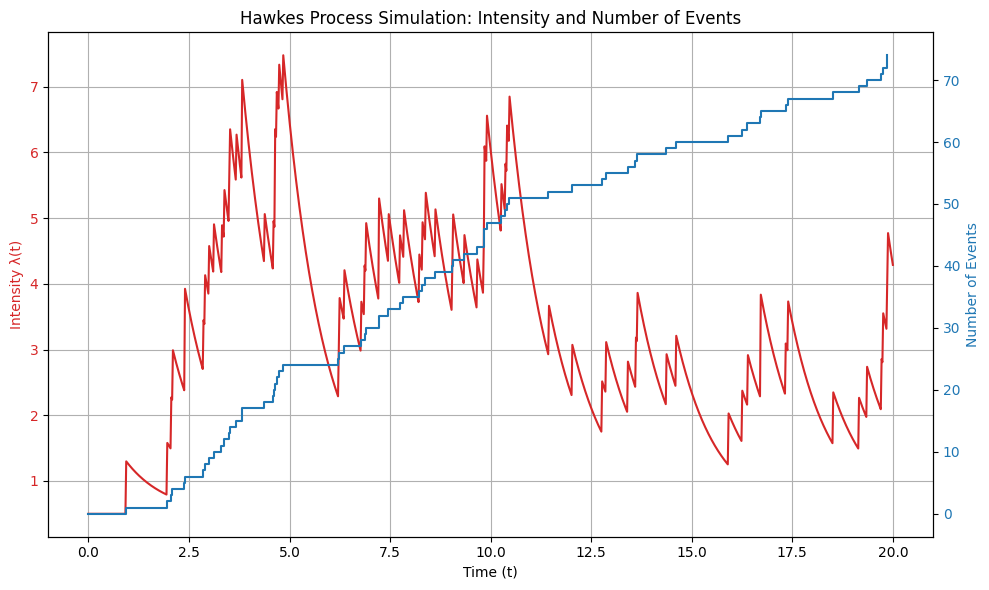

In [17]:

def plot_hawkes_process(mu, alpha, beta, T, event_times, num_intensity_points=1000):
    """
    Calculates and plots the conditional intensity lambda(t) and the cumulative number of events
    of a Hawkes process with an exponential kernel.

    Args:
        mu (float): The baseline intensity.
        alpha (float): The triggering parameter.
        beta (float): The decay parameter.
        T (float): The total simulation time (for defining time points).
        event_times (numpy.ndarray): An array of the event times of the Hawkes process.
        num_intensity_points (int): Number of points to evaluate lambda(t) for plotting.
    """

    time_points_intensity = np.linspace(0, T, num_intensity_points)
    lambda_values = np.zeros(num_intensity_points)

    for i, t_eval in enumerate(time_points_intensity):
        intensity = mu
        for past_time in event_times[event_times <= t_eval]:
            intensity += alpha * np.exp(-beta * (t_eval - past_time))
        lambda_values[i] = intensity

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot the intensity on the left y-axis
    color = 'tab:red'
    ax1.set_xlabel('Time (t)')
    ax1.set_ylabel('Intensity λ(t)', color=color)
    ax1.plot(time_points_intensity, lambda_values, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    # Create a second y-axis for the Hawkes value (cumulative events)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Number of Events', color=color)
    # Create step-like plot for the cumulative number of events
    ax2.step(np.concatenate([[0], event_times]), np.arange(len(event_times) + 1), where='post', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Hawkes Process Simulation: Intensity and Number of Events')
    fig.tight_layout()
    plt.show()

# Example Usage
mu = 0.5
alpha = 0.8
beta = 1.0
T = 20
history_times, history_lambda = simulate_hawkes_exponential_thinning(mu, alpha, beta, T)

plot_hawkes_process(mu, alpha, beta, T, history_times)

#### comparison

In [4]:
def test_hawkes_markov_property(mu, alpha, beta, T, delta_t, n_simulations=10000):
    """
    Tests the Markov property of the Hawkes process by comparing:
    1) Probability of at least one jump in (T/2, T/2 + delta_t) in original process
    2) Probability of at least one jump in (0, delta_t) in new process initialized with state at T/2
    """
    original_probs = []
    new_probs = []
    
    for _ in range(n_simulations):
        # 1. Simulate original process up to T
        original_times, original_lambdas = simulate_hawkes_exponential_thinning(mu, alpha, beta, T)
        
        # 2. Find state at T/2 (last event time and lambda before T/2)
        events_before_T_half = original_times[original_times <= T/2]
        
        if len(events_before_T_half) > 0:
            Tn = events_before_T_half[-1]  # Last event time before T/2
            # Calculate lambda at Tn (which is stored in original_lambdas)
            lambda_Tn = original_lambdas[np.where(original_times == Tn)[0][0]]
        else:
            Tn = None
            lambda_Tn = mu  # If no events before T/2, intensity is baseline
        
        # 3. Calculate probability in original process (T/2, T/2 + delta_t)
        jumps_in_original = np.sum((original_times > T/2) & (original_times <= T/2 + delta_t))
        original_probs.append(jumps_in_original > 0)
        
        # 4. Simulate new process with initial state from T/2
        new_times, _ = simulate_hawkes_exponential_thinning(
            mu, alpha, beta, 
            delta_t,  # Only simulate for delta_t time
            initial_history_time=Tn, 
            initial_lambda_history=lambda_Tn
        )

        # 5. Calculate probability in new process (0, delta_t)
        jumps_in_new = len(new_times)
        new_probs.append(jumps_in_new > 0)
    
    # Calculate average probabilities
    avg_original = np.mean(original_probs)
    avg_new = np.mean(new_probs)
    
    print(f"Average P(jump in (T/2, T/2+Δt)): {avg_original:.4f}")
    print(f"Average P(jump in (0, Δt) in new process): {avg_new:.4f}")
    print(f"Difference: {abs(avg_original - avg_new):.4f}")
    if abs(avg_original - avg_new) < 0.1:
        print("Let's go! It's Markov!!!.")
    
    return avg_original, avg_new

# Parameters
mu = 0.5
alpha = 0.3
beta = 1.0
T = 10.0
delta_t = 0.2  # Small time interval to check
n_simulations = 100000

# Run test
orig_prob, new_prob = test_hawkes_markov_property(mu, alpha, beta, T, delta_t, n_simulations)

Average P(jump in (T/2, T/2+Δt)): 0.1296
Average P(jump in (0, Δt) in new process): 0.1298
Difference: 0.0002
Let's go! It's Markov!!!.


## 📚 References

🔹 **Alan Hawkes**  
*Spectra of Some Self-Exciting and Mutually Exciting Point Processes*  
📄 [Read PDF](https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=c08206b44dd1f0ea54bd073e4effaf2e4483169b)



🔹 **Patrick J. Laub, Young Lee, Thomas Taimre**  
*The Elements of Hawkes Processes*  
📄 [Read PDF](https://webmail.polytechnique.fr/service/home/~/?auth=co&loc=fr_FR&id=2262&part=2)



🔹 **Thomas Liniger**  
*Multivariate Hawkes Processes*  
📄 [Read PDF](https://www.research-collection.ethz.ch/bitstream/handle/20.500.11850/151886/eth-1112-02.pdf)



🔹 **Yoshihiko Ogata**  
*On Lewis’ Simulation Method for Point Processes*  
📄 [Read PDF](https://pdfs.semanticscholar.org/9fb1/0a3c2dcec939784ce208e0e7e7fda4be895c.pdf)